In [4]:
from pathlib import Path

import numpy as np
import pandas as pd
import rasterio

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [5]:
root_data = Path("./data")

keywords = ["data", "queich", "pet"]
csv_paths = [
    f for f in root_data.rglob("*.csv") 
    if any(k in f.name for k in keywords)
    ]
csv_paths

[WindowsPath('data/abfluss_queich_siebeldingen/data/abfluss_queich_siebeldingen.csv'),
 WindowsPath('data/pet/all_pet.csv'),
 WindowsPath('data/precipitation_bad_bergzabern/data/data_OBS_DEU_P1D_RR_377.csv'),
 WindowsPath('data/precipitation_dahn/data/data_OBS_DEU_P1D_RR.csv'),
 WindowsPath('data/precipitation_pirmasens/data/data_3939.csv'),
 WindowsPath('data/snow_bad_bergzabern/data/data_OBS_DEU_P1D_SH.csv'),
 WindowsPath('data/snow_dahn/data/data_OBS_DEU_P1D_SH-N_19797.csv'),
 WindowsPath('data/snow_pirmasens/data/data_OBS_DEU_P1D_SH.csv'),
 WindowsPath('data/temp_mean_2m_bad_bergzabern/data/data_OBS_DEU_P1D_T2M_377.csv'),
 WindowsPath('data/temp_mean_2m_pirmasens/data/data_3939.csv')]

#### Dataframes

In [ ]:
df_dict = {
    p.parent.parent.stem: pd.read_csv(
        filepath_or_buffer=p, 
        sep=",", 
        index_col=False
        ) for p in csv_paths
    }

In [4]:
df_queich = df_dict["abfluss_queich_siebeldingen"]
df_discharge = df_queich[df_queich["Parameter"] == "Abfluss am Pegel"]

In [5]:
df_series_dict = {}
for key, df in df_dict.items():
    if key != "abfluss_queich_siebeldingen":
        df_series = pd.Series(df["Wert"].values, index=df["Zeitstempel"])
        df_series.index = pd.to_datetime(df_series.index)
        df_series_dict[key] = df_series
        
    if key == "abfluss_queich_siebeldingen":
        df_series = pd.Series(df["Wert"].values, index=df["Datum"])
        df_series.index = pd.to_datetime(df_series.index, format="%d.%m.%Y")
        df_series_dict[key] = df_series

In [6]:
df_series_dict.keys()

dict_keys(['abfluss_queich_siebeldingen', 'precipitation_bad_bergzabern', 'precipitation_dahn', 'precipitation_pirmasens', 'snow_bad_bergzabern', 'snow_dahn', 'snow_pirmasens', 'temp_mean_2m_badb_bergzabern', 'temp_mean_2m_pirmasens'])

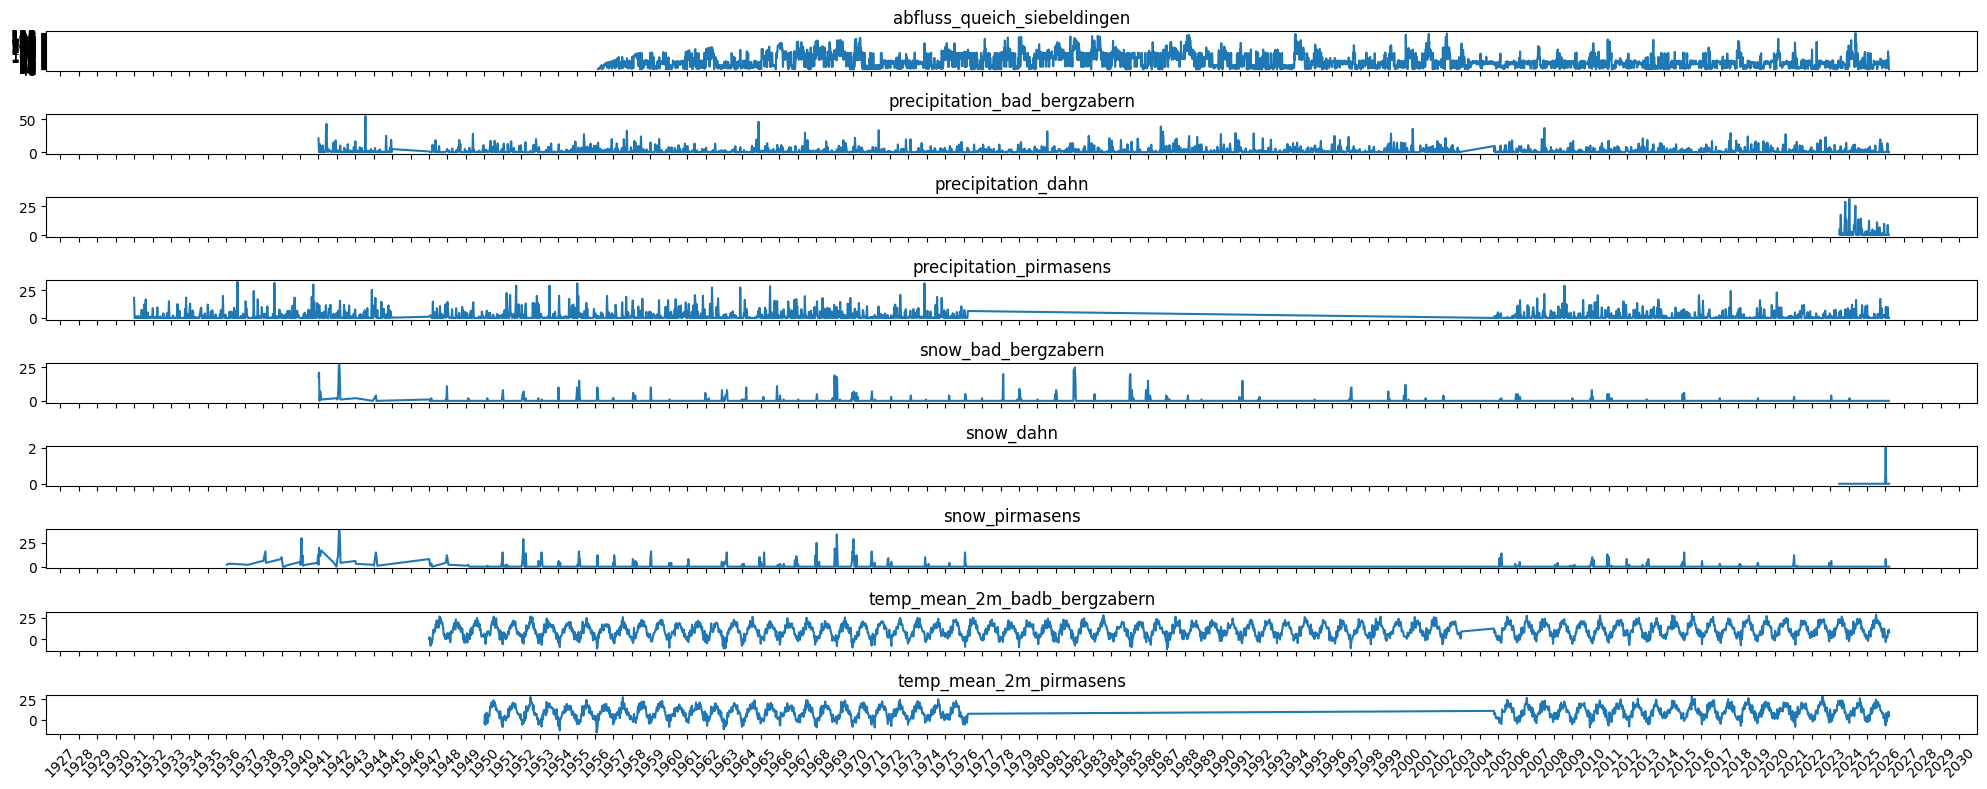

In [7]:
nrows = len(df_series_dict.keys())

fig, ax = plt.subplots(nrows=nrows, figsize=(20, 8), sharex=True)
# ax = ax.flatten()

for i, (key, df) in enumerate(df_series_dict.items()):
    df = df[::10]
    
    ax[i].plot(df)

    # Set monthly ticks
    ax[i].xaxis.set_major_locator(mdates.YearLocator())
    ax[i].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

    ax[i].tick_params(axis="x", rotation=45)
    
    ax[i].set_title(key)

plt.tight_layout()
plt.show()

#### XGBOOST - Prepare data

##### Discharge

In [6]:
# Read discharge data
discharge_path = csv_paths[0]
df_queich = pd.read_csv(discharge_path, sep=",", decimal=",")

df_discharge = df_queich[df_queich["Parameter"] == "Abfluss am Pegel"]
df_discharge.reset_index(inplace=True, drop=True)
# df_discharge

In [7]:
df_Q = df_discharge[["Datum", "Wert"]].copy()

df_Q["date"] = pd.to_datetime(df_Q["Datum"], format="%d.%m.%Y")
df_Q.drop(columns=["Datum"], inplace=True)
df_Q_sub = df_Q[df_Q["date"] > "2005-01-01"]

# Sort by date
df_Q_sub.sort_values(by="date", inplace=True)
df_Q_sub.reset_index(inplace=True, drop=True)

# df_Q_sub

C:\Users\Administrator\AppData\Local\Temp\ipykernel_14532\2063561311.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_Q_sub.sort_values(by="date", inplace=True)


##### Temperature & Precip

In [283]:
exclude=["dahn", "pirmasens"]

pet_paths = [p for p in csv_paths if "pet" in p.parts[1]]
temp_paths = [p for p in csv_paths if "temp" in p.parts[1]]
precip_paths = [p for p in csv_paths if "precip" in p.parts[1] and "dahn" not in p.parts[1]]

In [301]:
def read_format_pet(path: str | Path):
    
    df = pd.read_csv(pet_paths[0], sep=",", decimal=",",  index_col=False)
    df = df[["Unnamed: 0", "Bad Bergzabern"]].copy()
    df.columns = ["date", "pet"]

    df["pet"] = pd.to_numeric(df["pet"])
    df["date"] = pd.to_datetime(df["date"], format="%Y-%m-%d")

    df = df[df["date"] > "2005-01-01"]

    df = (
        df.sort_values(by="date")
        .reset_index(drop=True)    
    )

    return df

df_pet_merged = read_format_pet(pet_paths[0])

In [262]:
from typing import List

def read_format_df(path: str | Path) -> tuple[str, pd.DataFrame]:
    path = Path(path)
    location = path.parts[1].split("_")[-1]
    
    df = pd.read_csv(path, sep=",", decimal=",", index_col=False)
    
    df = df[["Zeitstempel", "Wert"]].copy()
    
    df["Wert"] = pd.to_numeric(df["Wert"])
    df["date"] = pd.to_datetime(df["Zeitstempel"], format="%Y-%m-%d")
    
    df = (
        df.drop(columns="Zeitstempel")
          .sort_values(by="date")
          .reset_index(drop=True)    
    )
    
    df = df[df["date"] > "2005-01-01"]
    
    return location, df

def read_dfs_merge(paths: List[str | Path]) -> pd.DataFrame:
    dfs = []
    loc_list = []
    
    for path in paths:
        location, df = read_format_df(path)
        loc_list.append(location)
        dfs.append(df)

    df_merged = pd.merge(
        left=dfs[0],
        right=dfs[1],
        on="date",
        how="inner",
        suffixes=(f"_{loc_list[0]}", f"_{loc_list[1]}"))  
    
    return df_merged


# df_temp_merged =read_dfs_merge(temp_paths[:1])
# df_precip_merged = read_dfs_merge(precip_paths[:1])

_, df_temp_merged =read_format_df(temp_paths[0])
_, df_precip_merged = read_format_df(precip_paths[0])

##### Merge all together

In [396]:
dfs = [
    df_Q_sub,
    df_temp_merged,
    df_precip_merged,
    df_pet_merged
    ]

dfs = [df.set_index("date") for df in dfs]    
    
# col_names = ["Q", "temp_bb", "temp_ps", "precip_bb", "precip_ps"]
col_names = ["Q", "temp_bb", "precip_bb", "pet_bb"]

df_all = pd.concat(dfs, axis=1)
df_all.columns = col_names
# df_all


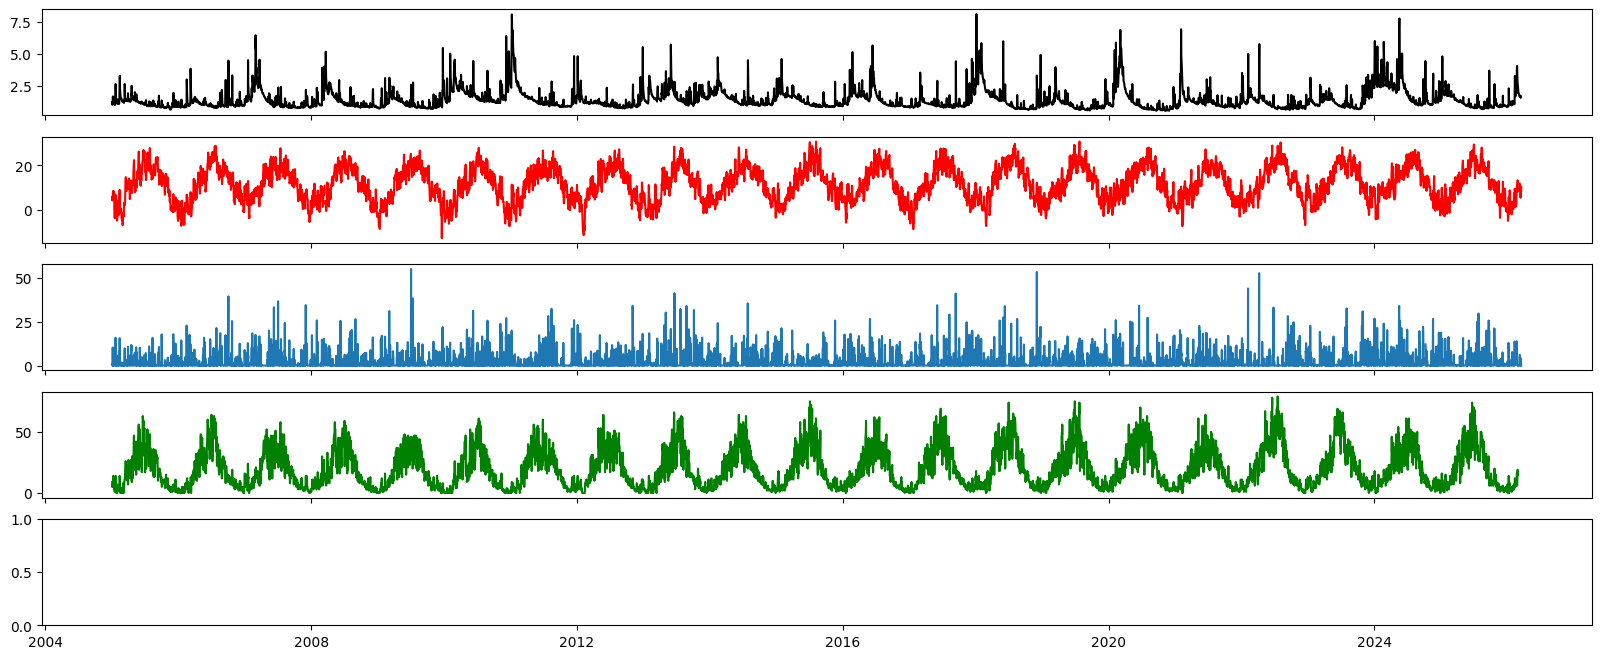

In [367]:
fig, axs = plt.subplots(nrows=5, figsize=(20, 8), sharex=True)

axs[0].plot(df_all["Q"], color = "black")
axs[1].plot(df_all["temp_bb"], color="red")
axs[2].plot(df_all["precip_bb"])
axs[3].plot(df_all["pet_bb"], color="green")
# axs[2].plot(df_all["temp_ps"], color="red")
# axs[4].plot(df_all["precip_ps"])

plt.show()

#### XGBOOST - Train Model

In [227]:
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error

##### Add date transform, lag and sum to data

In [397]:
# Add sin cos date transform to data
df_all["doy_sin"] = np.sin(2*np.pi * df_all.index.dayofyear/365)
df_all["doy_cos"] = np.cos(2*np.pi * df_all.index.dayofyear/365)


for col in df_all.columns:
    if "precip" in col or "temp" in col or "pet" in col:
        for lag in range(1, 14):
            df_all[f"{col}_{lag}"] = df_all[col].shift(lag)
    
    if "precip" in col:
        for d in [3, 7, 14]:
            df_all[f"{col}_sum_{d}"] = df_all[col].rolling(d).sum()

df_all["target"] = df_all["Q"].shift(-1)

df_all.dropna(inplace=True)

df_all

,Q,temp_bb,precip_bb,pet_bb,doy_sin,doy_cos,temp_bb_1,temp_bb_2,temp_bb_3,temp_bb_4,...,pet_bb_5,pet_bb_6,pet_bb_7,pet_bb_8,pet_bb_9,pet_bb_10,pet_bb_11,pet_bb_12,pet_bb_13,target
date,,,,,,,,,,,,,,,,,,,,,
2005-01-15,1.0014,0.4,0.0,3.0,0.255353,0.966848,2.6,4.7,7.7,6.7,...,7.0,5.0,14.0,6.0,7.0,5.0,7.0,5.0,9.0,0.9966
2005-01-16,0.9966,-3.6,0.0,1.0,0.271958,0.962309,0.4,2.6,4.7,7.7,...,5.0,7.0,5.0,14.0,6.0,7.0,5.0,7.0,5.0,0.9685
2005-01-17,0.9685,0.7,3.9,3.0,0.288482,0.957485,-3.6,0.4,2.6,4.7,...,4.0,5.0,7.0,5.0,14.0,6.0,7.0,5.0,7.0,1.5600
2005-01-18,1.5600,4.0,12.5,6.0,0.304921,0.952378,0.7,-3.6,0.4,2.6,...,6.0,4.0,5.0,7.0,5.0,14.0,6.0,7.0,5.0,1.3606
2005-01-19,1.3606,2.9,2.0,6.0,0.321270,0.946988,4.0,0.7,-3.6,0.4,...,3.0,6.0,4.0,5.0,7.0,5.0,14.0,6.0,7.0,1.3530
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-24,4.0367,10.9,4.9,6.0,0.811539,0.584298,10.7,10.1,8.1,3.8,...,6.0,8.0,11.0,11.0,7.0,5.0,9.0,12.0,10.0,3.2476
2026-02-25,3.2476,9.8,0.1,10.0,0.821477,0.570242,10.9,10.7,10.1,8.1,...,6.0,6.0,8.0,11.0,11.0,7.0,5.0,9.0,12.0,2.8841
2026-02-26,2.8841,10.8,0.0,14.0,0.831171,0.556017,9.8,10.9,10.7,10.1,...,9.0,6.0,6.0,8.0,11.0,11.0,7.0,5.0,9.0,2.6902


##### Split data

In [398]:
def split_date(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """Performs a 70, 20, 10 split of the dataframe"""


# 70 / 20 / 10 split
train_idx = int(len(df_all) * 0.6)
val_idx = train_idx + int(len(df_all) * 0.2)

df_train = df_all.iloc[:train_idx]
df_val = df_all.iloc[train_idx:val_idx]
df_test = df_all.iloc[val_idx:]

print(f"Full size: {len(df_all)}")
print(f"Train size: {len(df_train)}")
print(f"Val size: {len(df_val)}")
print(f"Test size: {len(df_test)}")

Full size: 7680
Train size: 4608
Val size: 1536
Test size: 1536


In [399]:
skipcols = ["target", "date", "Q"]
feature_cols = [col for col in df_all.columns if col not in skipcols]
print(feature_cols)

X_train = df_train[feature_cols]
y_train = df_train["target"]

X_val = df_val[feature_cols]
y_val = df_val["target"]

X_test = df_test[feature_cols]
y_test = df_test["target"]

['temp_bb', 'precip_bb', 'pet_bb', 'doy_sin', 'doy_cos', 'temp_bb_1', 'temp_bb_2', 'temp_bb_3', 'temp_bb_4', 'temp_bb_5', 'temp_bb_6', 'temp_bb_7', 'temp_bb_8', 'temp_bb_9', 'temp_bb_10', 'temp_bb_11', 'temp_bb_12', 'temp_bb_13', 'precip_bb_1', 'precip_bb_2', 'precip_bb_3', 'precip_bb_4', 'precip_bb_5', 'precip_bb_6', 'precip_bb_7', 'precip_bb_8', 'precip_bb_9', 'precip_bb_10', 'precip_bb_11', 'precip_bb_12', 'precip_bb_13', 'precip_bb_sum_3', 'precip_bb_sum_7', 'precip_bb_sum_14', 'pet_bb_1', 'pet_bb_2', 'pet_bb_3', 'pet_bb_4', 'pet_bb_5', 'pet_bb_6', 'pet_bb_7', 'pet_bb_8', 'pet_bb_9', 'pet_bb_10', 'pet_bb_11', 'pet_bb_12', 'pet_bb_13']


##### Train model

In [415]:
model = XGBRegressor(
    n_estimators=4000,
    max_depth=8,
    learning_rate=0.005,
    # subsample=0.8,
    # colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    early_stopping_rounds=20
)

In [416]:
model.fit(
    X_train, 
    y_train,
    eval_set=[(X_val, y_val)],
    )

[0]	validation_0-rmse:0.91761
[1]	validation_0-rmse:0.91603
[2]	validation_0-rmse:0.91443
[3]	validation_0-rmse:0.91284
[4]	validation_0-rmse:0.91129
[5]	validation_0-rmse:0.90974
[6]	validation_0-rmse:0.90820
[7]	validation_0-rmse:0.90665
[8]	validation_0-rmse:0.90513
[9]	validation_0-rmse:0.90360
[10]	validation_0-rmse:0.90203
[11]	validation_0-rmse:0.90052
[12]	validation_0-rmse:0.89905
[13]	validation_0-rmse:0.89751
[14]	validation_0-rmse:0.89603
[15]	validation_0-rmse:0.89451
[16]	validation_0-rmse:0.89309
[17]	validation_0-rmse:0.89163
[18]	validation_0-rmse:0.89016
[19]	validation_0-rmse:0.88872
[20]	validation_0-rmse:0.88729
[21]	validation_0-rmse:0.88587
[22]	validation_0-rmse:0.88447
[23]	validation_0-rmse:0.88304
[24]	validation_0-rmse:0.88157
[25]	validation_0-rmse:0.88017
[26]	validation_0-rmse:0.87878
[27]	validation_0-rmse:0.87743
[28]	validation_0-rmse:0.87600
[29]	validation_0-rmse:0.87457
[30]	validation_0-rmse:0.87321
[31]	validation_0-rmse:0.87181
[32]	validation_0-

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,20
,enable_categorical,False
,eval_metric,None


RMSE: 0.599


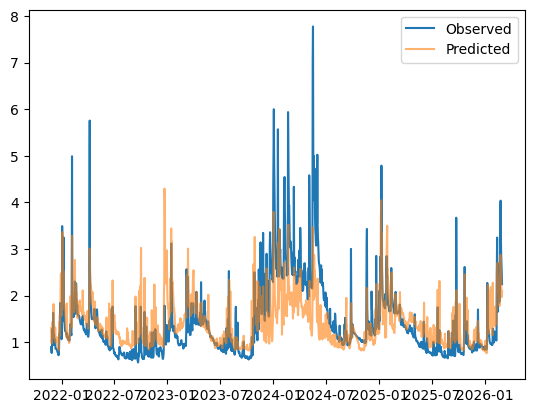

In [417]:
# test_set = (X_train, y_train)
# test_set = (X_val, y_val)
test_set = (X_test, y_test)

y_pred = model.predict(test_set[0])

rmse = np.sqrt(mean_squared_error(test_set[1], y_pred))
print(f"RMSE: {rmse:.3f}")

plt.plot(test_set[1].index, test_set[1], label="Observed")
plt.plot(test_set[1].index, y_pred, label="Predicted", alpha=0.6)
plt.legend()
plt.show()

In [ ]:
import streamlit as st

if "df" not in st.session_state:
    st.session_state.df = pd.DataFrame(np.random.randn(20, 2), columns=["x", "y"])

st.header("Choose a datapoint color")
color = st.color_picker("Color", "#FF0000")
st.divider()
st.scatter_chart(st.session_state.df, x="x", y="y", color=color)

2026-04-23 23:57:23.634 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-23 23:57:23.643 WARNING streamlit.runtime.state.session_state_proxy: Session state does not function when running a script without `streamlit run`
2026-04-23 23:57:23.671 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-23 23:57:23.679 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-23 23:57:23.679 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-23 23:57:24.497 
  command:

    streamlit run C:\Users\Administrator\App

DeltaGenerator()